# Logistic Regression from Scratch

A step-by-step implementation of Logistic Regression using Gradient Descent,
with no scikit-learn used in the modeling process.

The goal is to understand the intuition behind classification:
- From linear score to probability
- Sigmoid function
- Binary cross-entropy loss
- Gradients
- Gradient descent
- Decision boundary

## Problem

We want to predict whether a student passes or fails based on
the number of hours they studied.

Instead of predicting a continuous value like marks, our target is binary:

- `0` → Fail
- `1` → Pass

So our problem becomes:

`Hours Studied → Probability of Passing → Pass/Fail`

In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Loading Data 
df = pd.read_csv('data/weekly hours studied vs marks.csv')

print('Shape of DF :', df.shape)

df.head()

Shape of DF : (100, 2)


,Hours,Marks
0,40,98
1,37,40
2,28,68
3,12,33
4,15,80


In [4]:
# Creating out Binary Target
# a new column 'Passed' based on the condition if Marks > 50
df['Passed'] = (df['Marks'] > 50).astype(int)
df.head()

,Hours,Marks,Passed
0,40,98,1
1,37,40,0
2,28,68,1
3,12,33,0
4,15,80,1


## Can Linear Regression solve this problem?

Before introducing Logistic Regression, let's see what happens
if we use the Linear Regression.

Our model is:

prediction = w × Hours + b

But our target is now binary:

0 → Fail
1 → Pass

Let's see what kind of predictions a linear model produces.

In [5]:
# Linear score using the formula z = w * X + b

X = df["Hours"].values
y = df["Passed"].values

w = 0.05
b = -0.5

z = w * X + b

df["Linear_Prediction"] = z

df[["Hours", "Passed", "Linear_Prediction"]].head(10)

,Hours,Passed,Linear_Prediction
0,40,1,1.50
1,37,0,1.35
2,28,1,0.90
3,12,0,0.10
4,15,1,0.25
5,33,1,1.15
6,24,1,0.70
7,39,1,1.45
8,17,0,0.35
9,22,0,0.60


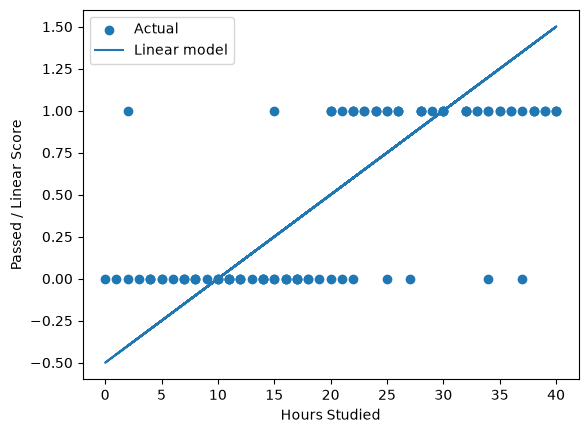

In [6]:
# visualize the linear predictions

plt.scatter(X, y, label="Actual")
plt.plot(X, z, label="Linear model")

plt.xlabel("Hours Studied")
plt.ylabel("Passed / Linear Score")
plt.legend()
plt.show()

## Why do we need the Sigmoid function?

From the plot above, we can see that our linear model produces a
continuous **linear score**.

The score is calculated as:

z = w × x + b

But there is a problem.

Our target represents two classes:

- `0` → Fail
- `1` → Pass

So we would like our model's output to behave like a probability,
where:

0 ≤ probability ≤ 1

However, our linear model can produce values outside this range.

For example, in the plot:

- Some predictions are below `0`
- Some predictions are above `1`

These values don't make sense as probabilities.

We therefore need a function that takes any linear score `z` and
squashes it into the range `(0, 1)`.

That function is the **Sigmoid function**.

Our model will therefore become:

Linear score:

z = w × x + b

↓

Sigmoid transformation:

p = sigmoid(z)

↓

Probability of belonging to class `1`

The important idea is:

**Logistic Regression still uses the same linear score we know from
Linear Regression. The sigmoid simply converts that score into a
probability.**

In [7]:
# Sigmoid Function

# The linear model gives us a score:
#     z = w * x + b

# This score can be any value from -infinity to +infinity.
# But we want to interpret our model's output as a probability,
# so we need to convert this score into a value between 0 and 1.

# The sigmoid function does exactly that:

#     z → sigmoid(z) → probability

# Important intuition:
#     Large negative z → probability close to 0
#     z = 0            → probability = 0.5
#     Large positive z → probability close to 1

def sigmoid(z):
    """
    Convert a linear score into a probability between 0 and 1.
    formula :σ(z)= 1/(1+e^−z)
    """
    
    return 1 / (1 + np.exp(-z))

# Test the sigmoid with different linear scores

values = np.array([-10, -2, 0, 2, 10])

print(sigmoid(values))

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


# Visualising the Sigmoid Funciton

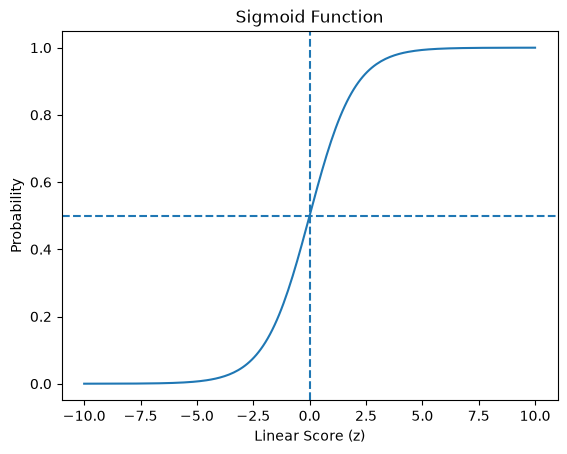

In [8]:
# Generate a range of linear scores
z_values = np.linspace(-10, 10, 200)

# Convert each score into a probability
probabilities = sigmoid(z_values)

# Plot the sigmoid curve
plt.plot(z_values, probabilities)

# Add reference lines
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Linear Score (z)")
plt.ylabel("Probability")
plt.title("Sigmoid Function")

plt.show()

## From Probability to Class

Our sigmoid function gives us a probability:

p = sigmoid(z)

For example:

- `p = 0.90` → model is strongly leaning toward Pass
- `p = 0.70` → model is leaning toward Pass
- `p = 0.50` → model is uncertain
- `p = 0.20` → model is leaning toward Fail
- `p = 0.05` → model is strongly leaning toward Fail

But our actual target is still binary:

- `0` → Fail
- `1` → Pass

So eventually, we need to convert the probability into a class.

A common approach is to use `0.5` as the decision threshold:

    probability >= 0.5 → class 1
    probability <  0.5 → class 0

However, for now we will keep the probability and the final
classification separate.

The model predicts a **probability**.

The threshold makes the **decision**.

In [9]:
# Convert our linear scores into probabilities
#
# We already calculated:
#
#     z = w * X + b
#
# Now we pass those scores through the sigmoid function:
#
#     probability = sigmoid(z)

probabilities = sigmoid(z)

# Store the probabilities in our DataFrame
df["Probability"] = probabilities

# Look at the result
df[["Hours", "Passed", "Linear_Prediction", "Probability"]].head(10)

,Hours,Passed,Linear_Prediction,Probability
0,40,1,1.50,0.817574
1,37,0,1.35,0.794130
2,28,1,0.90,0.710950
3,12,0,0.10,0.524979
4,15,1,0.25,0.562177
5,33,1,1.15,0.759511
6,24,1,0.70,0.668188
7,39,1,1.45,0.809998
8,17,0,0.35,0.586618
9,22,0,0.60,0.645656


## How do we measure whether our predictions are good?

Our model now produces probabilities instead of raw scores.

For example:

    Actual:      1
    Prediction:  0.90

This is a good prediction.

But consider:

    Actual:      1
    Prediction:  0.01

This is a very bad prediction.

So we need a **loss function** that tells us how wrong our
predicted probability is.

For Logistic Regression, we use **Binary Cross-Entropy Loss**,
also called **Log Loss**.

The loss for one observation is:

    Loss = -[ y log(p) + (1-y) log(1-p) ]

where:

    y = actual class (0 or 1)
    p = predicted probability

The interesting part is how the loss behaves:

    Actual = 1

    p → 1       → small loss
    p → 0       → very large loss


    Actual = 0

    p → 0       → small loss
    p → 1       → very large loss

This means the loss strongly punishes the model when it is
**confident and wrong**.

Our goal during training will therefore be:

    Find w and b
    ↓
    that produce good probabilities
    ↓
    that minimize the Log Loss

In [10]:
# Binary Cross-Entropy / Log Loss for one observation
#
# y = actual class
# p = predicted probability
#
# Formula:
#
# Loss = -[ y * log(p) + (1-y) * log(1-p) ]

def log_loss_single(y, p):
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

In [11]:
# Actual class is 1 (Pass)

print("Good prediction :", log_loss_single(1, 0.9))
print("Okay prediction :", log_loss_single(1, 0.5))
print("Bad prediction  :", log_loss_single(1, 0.1))

Good prediction : 0.10536051565782628
Okay prediction : 0.6931471805599453
Bad prediction  : 2.3025850929940455


In [12]:
# Actual class is 0 (Fail)

print("Good prediction :", log_loss_single(0, 0.1))
print("Okay prediction :", log_loss_single(0, 0.5))
print("Bad prediction  :", log_loss_single(0, 0.9))

Good prediction : 0.10536051565782628
Okay prediction : 0.6931471805599453
Bad prediction  : 2.302585092994046


## Calculating the Loss for the Entire Dataset

So far, we calculated the loss for a single observation.

But our dataset contains many observations.

We therefore calculate the loss for every observation
and then take the average.

The cost function becomes:

    J(w,b) = -(1/m) Σ [ y log(p) + (1-y) log(1-p) ]

where:

    m = number of training examples
    y = actual class
    p = predicted probability

The idea is simple:

    Individual predictions
            ↓
       Individual losses
            ↓
        Average them
            ↓
       Overall model loss

Our goal during training will be to minimize this overall loss.

If the loss decreases, our model is generally getting better
at predicting the correct probabilities.

In [13]:
# Binary Cross-Entropy / Log Loss for the entire dataset
#
# We calculate the loss for every prediction
# and then take the average.
#
# Formula:
#
# J(w,b) = -(1/m) * Σ [y*log(p) + (1-y)*log(1-p)]

def compute_cost(y, p):
    """
    Calculate the average Binary Cross-Entropy loss.

    Parameters:
        y : actual target values (0 or 1)
        p : predicted probabilities

    Returns:
        Average log loss
    """

    m = len(y)

    loss = -(1 / m) * np.sum(
        y * np.log(p) + (1 - y) * np.log(1 - p)
    )

    return loss

In [14]:
# Calculate the current model's cost

cost = compute_cost(y, probabilities)

print("Cost:", cost)

Cost: 0.5665250984443897


## How do we improve the model?

Our current model has:

    w = 0.05
    b = -0.5

and produces:

    Cost = 0.5665

We want to find better values of `w` and `b` that reduce this cost.

We could manually try:

    w = 0.01
    w = 0.02
    w = 0.03
    ...

But this would be extremely inefficient.

Instead, we use **Gradient Descent**.

The idea is:

    1. Calculate the current cost
    2. Calculate the gradient
    3. Use the gradient to determine which direction to move
    4. Update `w` and `b`
    5. Repeat

The gradient tells us:

    "If I slightly change this parameter,
     will the cost increase or decrease?"

So instead of randomly changing `w` and `b`,
we use the gradient to move them in a direction
that reduces the cost.

Our goal is:

    Cost ↓

by repeatedly updating:

    w → better w
    b → better b

## Finding the Gradient

Our cost depends on `w` and `b`:

    J(w, b)

We want to know how changing each parameter affects the cost.

For `w`, we calculate:

    ∂J/∂w

For `b`, we calculate:

    ∂J/∂b

For Logistic Regression, after differentiating the
Binary Cross-Entropy loss, we get:

    ∂J/∂w = (1/m) Xᵀ(p - y)

    ∂J/∂b = (1/m) Σ(p - y)

where:

    p = predicted probability
    y = actual value
    m = number of training examples

The interesting part is:

    p - y

This is the prediction error.

For example:

    actual = 1
    prediction = 0.8

    p - y = 0.8 - 1
          = -0.2

The model predicted too low, so the gradient will
tell us how to adjust the parameters.

Another example:

    actual = 0
    prediction = 0.8

    p - y = 0.8 - 0
          = 0.8

The model predicted too high.

So the gradient is essentially using the prediction error
to determine how we should change `w` and `b`.

This is what connects our predictions to learning.

In [15]:
# Calculate the prediction error for each training example
#
# p = predicted probability
# y = actual class
#
# This tells us how far our prediction is from the actual answer.

errors = probabilities - y

# Add the errors to our DataFrame so we can inspect them
df["Error"] = errors

df[["Hours", "Passed", "Probability", "Error"]].head(10)

,Hours,Passed,Probability,Error
0,40,1,0.817574,-0.182426
1,37,0,0.794130,0.794130
2,28,1,0.710950,-0.289050
3,12,0,0.524979,0.524979
4,15,1,0.562177,-0.437823
5,33,1,0.759511,-0.240489
6,24,1,0.668188,-0.331812
7,39,1,0.809998,-0.190002
8,17,0,0.586618,0.586618
9,22,0,0.645656,0.645656


In [16]:
# Calculate gradients for w and b
#
# Gradient for w:
#
#     dw = (1/m) * Σ[(p - y) * x]
#
# Gradient for b:
#
#     db = (1/m) * Σ(p - y)
#
# The gradient tells us which direction each parameter
# should move to reduce the cost.

m = len(y)

dw = (1 / m) * np.sum(errors * X)
db = (1 / m) * np.sum(errors)

print("dw:", dw)
print("db:", db)

dw: 0.07627839970292448
db: 0.13287634070982487


## Updating `w` and `b`

We now know which direction the cost wants us to move.

We have:

    dw = gradient of the cost with respect to w
    db = gradient of the cost with respect to b

But we don't want to take a huge step.

We introduce a **learning rate** `α` that controls the size
of each update.

The update rules are:

    w_new = w - α × dw

    b_new = b - α × db

Why do we subtract?

The gradient points in the direction where the cost increases.

We want to move in the opposite direction:

    gradient direction
          ↑
          |
          |
          ●  current parameters
           \
            \
             ↓
        lower cost

So:

    new parameter = old parameter - learning_rate × gradient

We repeat this process again and again until the cost stops
decreasing significantly.

In [17]:
# Learning rate controls how big our step is
learning_rate = 0.01

# Save the current parameters before updating
old_w = w
old_b = b

# Gradient Descent update
w = w - learning_rate * dw
b = b - learning_rate * db

print("Old w:", old_w)
print("New w:", w)

print("Old b:", old_b)
print("New b:", b)

Old w: 0.05
New w: 0.049237216002970756
Old b: -0.5
New b: -0.5013287634070982


In [18]:
# Recalculate the linear scores using the updated parameters
z = w * X + b

# Convert the new scores into probabilities
probabilities = sigmoid(z)

# Calculate the new cost
new_cost = compute_cost(y, probabilities)

print("New cost:", new_cost)

New cost: 0.5663260424481072


## Training the Model with Gradient Descent

We successfully performed one gradient descent update.

But one update is not enough.

We want to repeat the same process many times:

    1. Calculate the linear score
           z = Xw + b

    2. Convert scores to probabilities
           p = sigmoid(z)

    3. Calculate the cost

    4. Calculate the prediction error
           error = p - y

    5. Calculate the gradients
           dw
           db

    6. Update the parameters
           w = w - α × dw
           b = b - α × db

    7. Repeat

Each iteration should ideally move us toward a lower cost.

We will keep track of the cost after every iteration so
we can visualize whether the model is actually learning.

In [41]:
# Train Logistic Regression using Gradient Descent

# Start with our manual parameters
w = 0.05
b = -0.5

# Learning rate controls the size of each update
learning_rate = 0.01

# Number of times we update w and b
iterations = 10000

# Store the cost after every iteration
cost_history = []

for i in range(iterations):

    # -----------------------------
    # 1. Forward pass
    # -----------------------------
    # Calculate the linear score
    z = w * X + b

    # Convert the score into probabilities
    probabilities = sigmoid(z)

    # -----------------------------
    # 2. Calculate the cost
    # -----------------------------
    cost = compute_cost(y, probabilities)

    # Keep track of the cost
    cost_history.append(cost)

    # -----------------------------
    # 3. Calculate the error
    # -----------------------------
    errors = probabilities - y

    # -----------------------------
    # 4. Calculate the gradients
    # -----------------------------
    m = len(y)

    dw = (1 / m) * np.sum(errors * X)
    db = (1 / m) * np.sum(errors)

    # -----------------------------
    # 5. Update parameters
    # -----------------------------
    w = w - learning_rate * dw
    b = b - learning_rate * db


print("Final w:", w)
print("Final b:", b)
print("Final cost:", cost_history[-1])

Final w: 0.20336503838141662
Final b: -4.195005418490137
Final cost: 0.3515286612106056


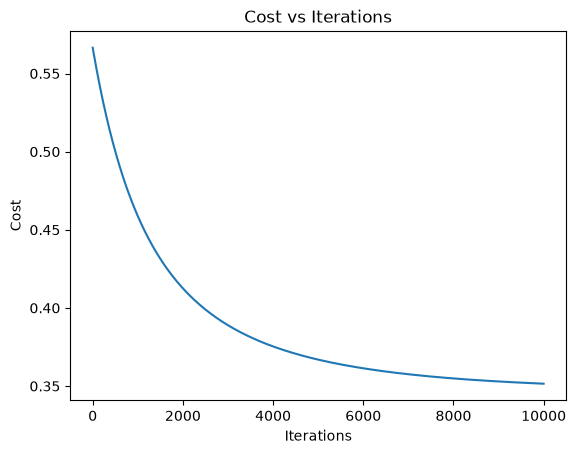

In [42]:
# Plot the cost over training iterations

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")

plt.show()

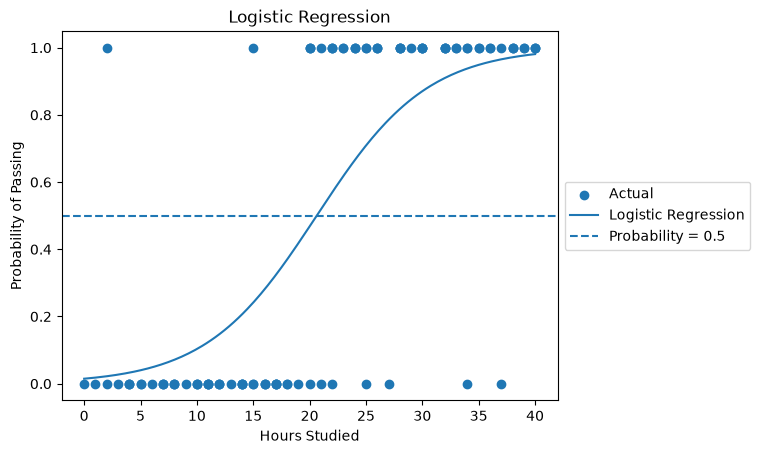

In [45]:
# Generate smooth Hours values for plotting
hours_plot = np.linspace(0, 40, 200)

# Calculate the linear score using the learned parameters
z_plot = w * hours_plot + b

# Convert the scores into probabilities
probabilities_plot = sigmoid(z_plot)

# Plot the actual Pass/Fail observations
plt.scatter(X, y, label="Actual")

# Plot the learned probability curve
plt.plot(
    hours_plot,
    probabilities_plot,
    label="Logistic Regression"
)

# Show the 0.5 probability threshold
plt.axhline(0.5, linestyle="--", label="Probability = 0.5")

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")

# Move legend to bottom right
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

## Conclusion

We built Logistic Regression from scratch to understand what is
happening underneath the algorithm.

Our model follows this process:

    Input features
          ↓
    Linear score
          ↓
      z = Xw + b
          ↓
       Sigmoid
          ↓
      Probability
          ↓
      Log Loss
          ↓
      Gradients
          ↓
    Gradient Descent
          ↓
       Update w,b
          ↓
        Repeat

The final visualization shows that the model has learned the
general relationship between hours studied and the probability
of passing.

Unlike Linear Regression, the output is now a probability between
0 and 1 rather than an unrestricted linear value.

The sigmoid allows the linear score to be interpreted as a
probability, while Binary Cross-Entropy gives us a way to measure
how good those probabilities are.

Gradient Descent then learns the parameters `w` and `b` by
repeatedly moving them in the direction that reduces the loss.

### Key intuition

**Logistic Regression is essentially a linear model followed by
a sigmoid function, trained by minimizing Binary Cross-Entropy
using Gradient Descent.**

We will leave classification thresholds and evaluation metrics
for a separate topic.